# PART 1 — Dataset Understanding and Cleaning

This section loads the dataset, checks missing values, handles review rating carefully, checks duplicate customer IDs, and standardizes text fields.

The goal is to understand the dataset before creating loyalty or segmentation logic.

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset (1).csv")

In [84]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [85]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [86]:
df["Review Rating Missing Flag"] = df["Review Rating"].isnull().astype(int)

review_rating_median = df["Review Rating"].median()

df["Review Rating"] = df["Review Rating"].fillna(review_rating_median)

In [87]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [88]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["Customer ID"].duplicated().sum())
print("Unique customers:", df["Customer ID"].nunique())
print("Total rows:", len(df))

Duplicate rows: 0
Duplicate Customer IDs: 0
Unique customers: 3900
Total rows: 3900


In [89]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


In [90]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

yes_no_columns = ["Subscription Status", "Discount Applied", "Promo Code Used"]

for column in yes_no_columns:
    df[column] = df[column].str.title()

# PART 2 — Exploratory Data Analysis

This section explores customer demographics, product categories, spending, subscription status, shipping, review ratings, discount usage, and purchase frequency.

These charts are descriptive only. They help us understand the customer base before creating engineered features.

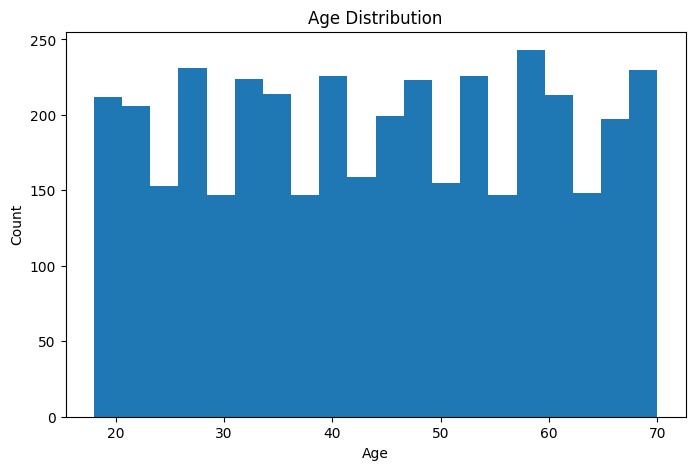

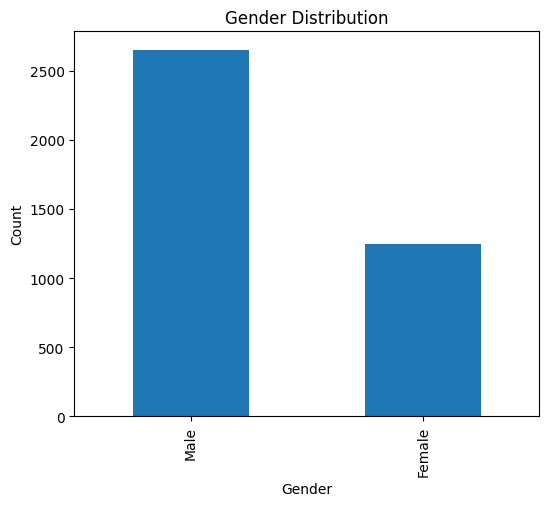

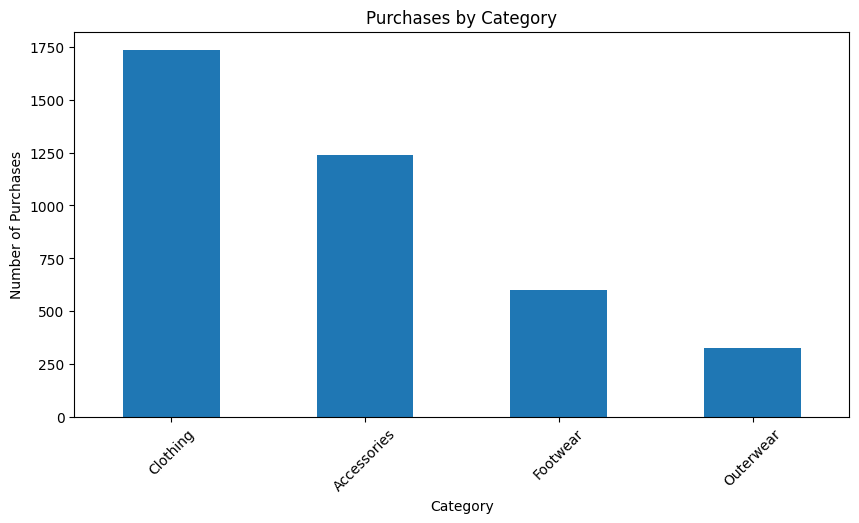

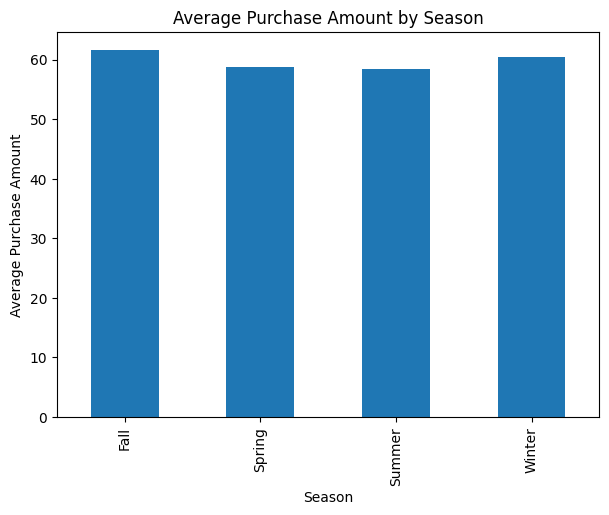

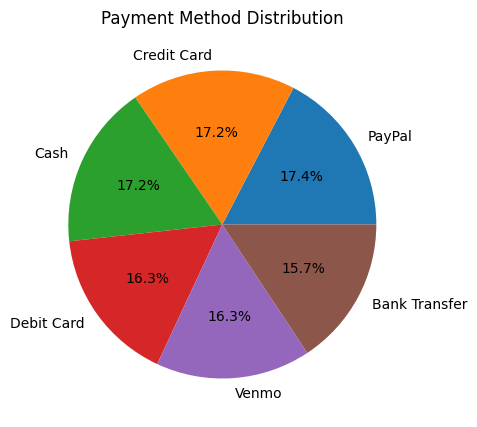

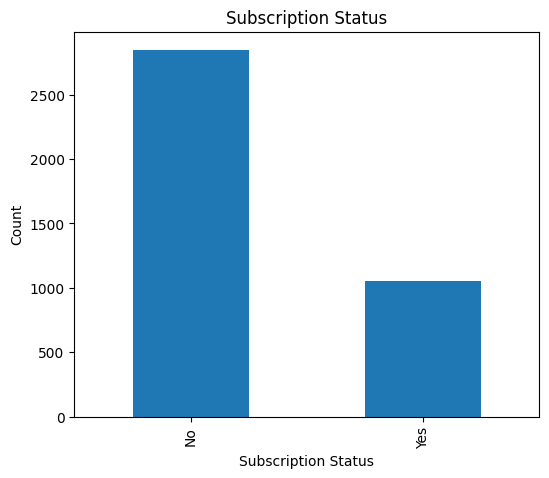

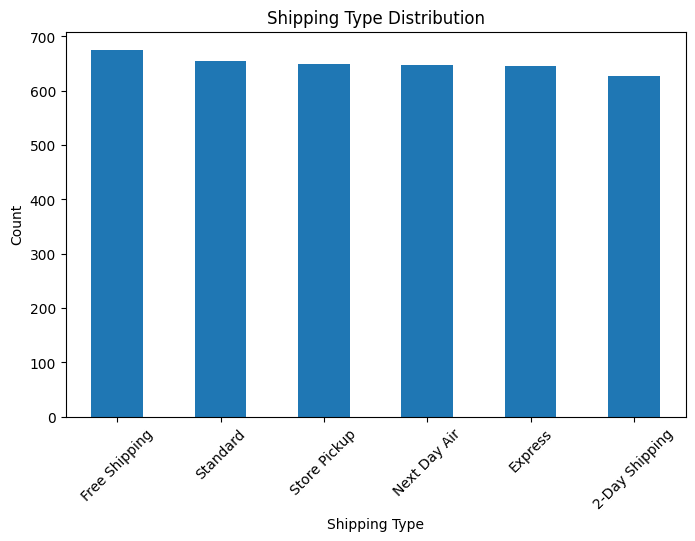

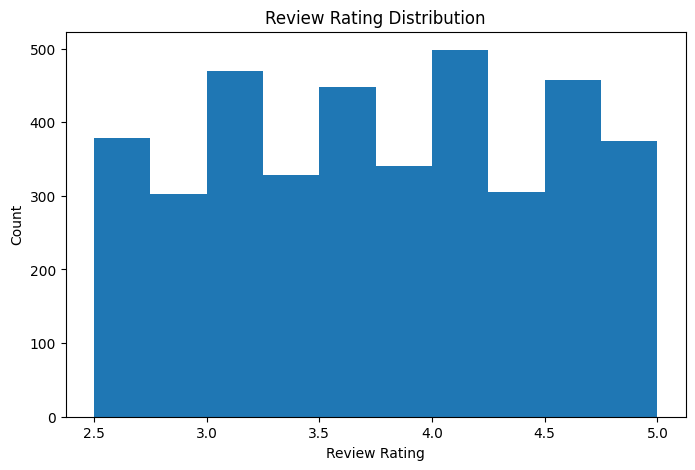

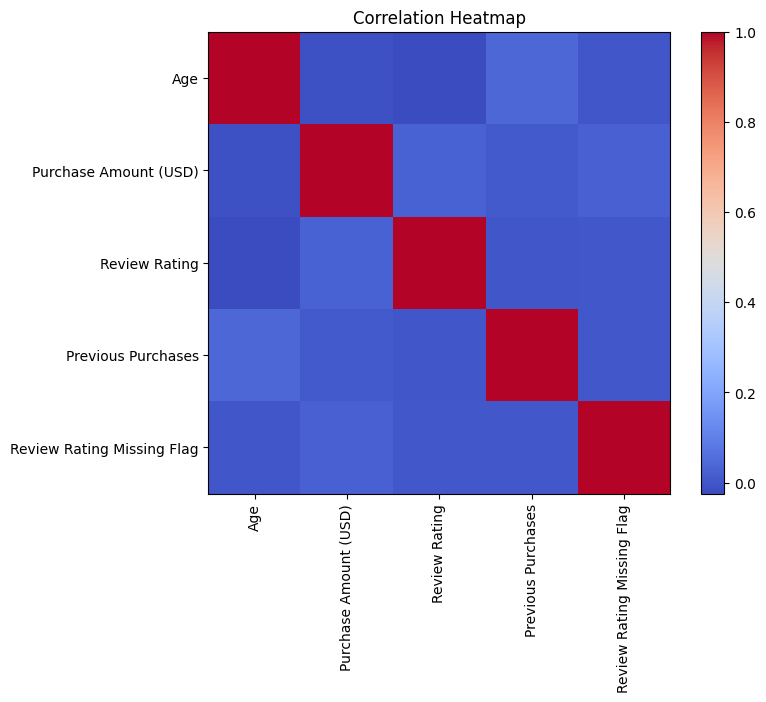

In [91]:
# -----------------------------
# 1. Age Distribution
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()


# -----------------------------
# 2. Gender Count
# -----------------------------
plt.figure(figsize=(6,5))
df['Gender'].value_counts().plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()


# -----------------------------
# 3. Category Wise Purchases
# -----------------------------
plt.figure(figsize=(10,5))
df['Category'].value_counts().plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Number of Purchases")
plt.title("Purchases by Category")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 4. Purchase Amount by Season
# -----------------------------
season_purchase = df.groupby('Season')['Purchase Amount (USD)'].mean()

plt.figure(figsize=(7,5))
season_purchase.plot(kind='bar')
plt.xlabel("Season")
plt.ylabel("Average Purchase Amount")
plt.title("Average Purchase Amount by Season")
plt.show()


# -----------------------------
# 5. Payment Method Usage
# -----------------------------
plt.figure(figsize=(8,5))
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()


# -----------------------------
# 6. Subscription Status
# -----------------------------
plt.figure(figsize=(6,5))
df['Subscription Status'].value_counts().plot(kind='bar')
plt.xlabel("Subscription Status")
plt.ylabel("Count")
plt.title("Subscription Status")
plt.show()


# -----------------------------
# 7. Shipping Type Distribution
# -----------------------------
plt.figure(figsize=(8,5))
df['Shipping Type'].value_counts().plot(kind='bar')
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.title("Shipping Type Distribution")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 8. Review Rating Distribution
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['Review Rating'], bins=10)
plt.xlabel("Review Rating")
plt.ylabel("Count")
plt.title("Review Rating Distribution")
plt.show()


# -----------------------------
# 9. Correlation Heatmap
# -----------------------------
numeric_df = df.select_dtypes(include=["int64", "float64"]).drop(
    columns=["Customer ID"],
    errors="ignore"
)

plt.figure(figsize=(8,6))
plt.imshow(numeric_df.corr(), cmap='coolwarm')

plt.colorbar()
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Heatmap")
plt.show()

In [92]:
df.groupby('Discount Applied').size()

,0
Discount Applied,
No,2223
Yes,1677


In [93]:
df.groupby('Frequency of Purchases').size()

,0
Frequency of Purchases,
Annually,572
Bi-Weekly,547
Every 3 Months,584
Fortnightly,542
Monthly,553
Quarterly,563
Weekly,539


# PART 3 — Feature Engineering

This section creates customer-level features that will later support loyalty scoring and segmentation.

Because the dataset has no timestamps or transaction history, several features are proxies rather than exact measures.

In [94]:
# Annualized frequency
frequency_map = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Fortnightly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1
}

df["purchase_frequency_annual"] = (
    df["Frequency of Purchases"].map(frequency_map)
)
df[df["purchase_frequency_annual"].isnull()]["Frequency of Purchases"].value_counts()

# Total purchases
df["purchase_count"] = (
    df["Previous Purchases"] + 1
)

# Repeat purchase ratio
df["repeat_purchase_ratio"] = (
    df["Previous Purchases"] / df["purchase_count"]
)

# Estimated lifetime spend
df["estimated_total_spend"] = (
    df["Purchase Amount (USD)"] * df["purchase_count"]
)

# Average order value proxy
df["avg_order_value_proxy"] = df["Purchase Amount (USD)"]

In [95]:
# Promo usage
df["promo_used_flag"] = np.where(
    (df["Discount Applied"] == "Yes") |
    (df["Promo Code Used"] == "Yes"),
    1,
    0
)

# Organic customer
df["organic_customer_flag"] = np.where(
    df["promo_used_flag"] == 0,
    1,
    0
)

# Discount dependency score
df["discount_dependency_score"] = (
    df["promo_used_flag"] * 100
)

# Low dependency flag
df["low_promo_dependency_flag"] = np.where(
    df["promo_used_flag"] == 0,
    1,
    0
)

In [96]:
# Satisfaction flag
df["satisfaction_flag"] = np.where(
    df["Review Rating"] >= 4,
    1,
    0
)

# Rating category
df["rating_segment"] = pd.cut(
    df["Review Rating"],
    bins=[0, 2, 3, 4, 5],
    labels=[
        "Poor",
        "Average",
        "Good",
        "Excellent"
    ]
)

In [97]:
# Subscription
df["subscription_flag"] = np.where(
    df["Subscription Status"] == "Yes",
    1,
    0
)

# Engagement score
df["engagement_score"] = (
    0.6 * df["subscription_flag"] +
    0.4 * df["satisfaction_flag"]
) * 100

#Part 4 Loyalty Score Construction and Comparison
The dataset does not contain a predefined loyalty score or churn label. Therefore, loyalty is constructed using available behavioral, value, satisfaction, and promo-related variables.

We created two competing loyalty definitions:

Behavioral Loyalty — identifies customers with strong repeat behavior and purchase frequency.
Value-Quality Loyalty — identifies customers who are valuable, satisfied, and less promo-dependent.
These definitions measure different forms of loyalty, so we compare them rather than assuming one is automatically correct.

In [98]:
# Percentile ranks
df["purchase_count_percentile"] = (
    df["purchase_count"].rank(pct=True)
)

df["frequency_percentile"] = (
    df["purchase_frequency_annual"].rank(pct=True)
)

# Behavioral loyalty score
df["behavioral_loyalty_score"] = (
    0.45 * df["purchase_count_percentile"]
    + 0.35 * df["frequency_percentile"]
    + 0.20 * df["repeat_purchase_ratio"]
) * 100

# Loyalty flag
repeat_threshold = df["repeat_purchase_ratio"].quantile(0.75)
frequency_threshold = df["purchase_frequency_annual"].median()
previous_purchase_threshold = df["Previous Purchases"].quantile(0.60)

df["behavioral_loyalty_flag"] = np.where(
    (df["repeat_purchase_ratio"] >= repeat_threshold)
    &
    (df["purchase_frequency_annual"] >= frequency_threshold)
    &
    (df["Previous Purchases"] >= previous_purchase_threshold),
    1,
    0
)

In [99]:
# Percentiles
df["spend_percentile"] = (
    df["estimated_total_spend"].rank(pct=True)
)

df["aov_percentile"] = (
    df["Purchase Amount (USD)"].rank(pct=True)
)

df["rating_percentile"] = (
    df["Review Rating"].rank(pct=True)
)

# Value-quality loyalty
df["value_quality_loyalty_score"] = (
    0.40 * df["spend_percentile"]
    + 0.25 * df["aov_percentile"]
    + 0.20 * df["rating_percentile"]
    + 0.15 * df["low_promo_dependency_flag"]
) * 100

# High-value loyalty
value_quality_threshold = df["value_quality_loyalty_score"].quantile(0.75)

df["value_quality_loyalty_flag"] = np.where(
    (df["value_quality_loyalty_score"] >= value_quality_threshold)
    &
    (df["satisfaction_flag"] == 1)
    &
    (df["low_promo_dependency_flag"] == 1),
    1,
    0
)

In [100]:
loyalty_comparison = pd.DataFrame({
    "Loyalty Definition": [
        "Behavioral Loyalty",
        "Value-Quality Loyalty"
    ],
    "Primary Question Answered": [
        "Who repeatedly buys from us?",
        "Who is valuable without needing discounts?"
    ],
    "Loyal Customers": [
        df["behavioral_loyalty_flag"].sum(),
        df["value_quality_loyalty_flag"].sum()
    ],
    "Customer Share %": [
        df["behavioral_loyalty_flag"].mean() * 100,
        df["value_quality_loyalty_flag"].mean() * 100
    ],
    "Avg Estimated Spend": [
        df.loc[df["behavioral_loyalty_flag"] == 1, "estimated_total_spend"].mean(),
        df.loc[df["value_quality_loyalty_flag"] == 1, "estimated_total_spend"].mean()
    ],
    "Avg Promo Usage": [
        df.loc[df["behavioral_loyalty_flag"] == 1, "promo_used_flag"].mean(),
        df.loc[df["value_quality_loyalty_flag"] == 1, "promo_used_flag"].mean()
    ],
    "Avg Review Rating": [
        df.loc[df["behavioral_loyalty_flag"] == 1, "Review Rating"].mean(),
        df.loc[df["value_quality_loyalty_flag"] == 1, "Review Rating"].mean()
    ]
})

loyalty_comparison.round(2)

,Loyalty Definition,Primary Question Answered,Loyal Customers,Customer Share %,Avg Estimated Spend,Avg Promo Usage,Avg Review Rating
0,Behavioral Loyalty,Who repeatedly buys from us?,533,13.67,2698.53,0.46,3.79
1,Value-Quality Loyalty,Who is valuable without needing discounts?,448,11.49,2563.68,0.00,4.51


In [101]:
pd.crosstab(
    df["behavioral_loyalty_flag"],
    df["value_quality_loyalty_flag"],
    rownames=["Behavioral Loyal"],
    colnames=["Value-Quality Loyal"]
)

Value-Quality Loyal,0,1
Behavioral Loyal,,
0,3021,346
1,431,102


In [102]:
def classify_loyalty(row):
    if row["behavioral_loyalty_flag"] == 1 and row["value_quality_loyalty_flag"] == 1:
        return "Loyal by Both Definitions"
    elif row["behavioral_loyalty_flag"] == 1:
        return "Behaviorally Loyal Only"
    elif row["value_quality_loyalty_flag"] == 1:
        return "Value-Quality Loyal Only"
    else:
        return "Not Loyal by Either Definition"

df["loyalty_classification"] = df.apply(classify_loyalty, axis=1)

loyalty_classification_summary = (
    df["loyalty_classification"]
    .value_counts()
    .reset_index()
)

loyalty_classification_summary.columns = [
    "loyalty_classification",
    "customer_count"
]

loyalty_classification_summary["customer_share_percent"] = (
    loyalty_classification_summary["customer_count"] / len(df) * 100
)

loyalty_classification_summary.round(2)

,loyalty_classification,customer_count,customer_share_percent
0,Not Loyal by Either Definition,3021,77.46
1,Behaviorally Loyal Only,431,11.05
2,Value-Quality Loyal Only,346,8.87
3,Loyal by Both Definitions,102,2.62


## Part 4 -Interpretation

Behavioral loyalty and value-quality loyalty measure different forms of loyalty.

Behavioral loyalty is better for identifying customers with strong repeat purchase behavior. These customers appear to buy frequently and have strong previous purchase history.

Value-quality loyalty is better for promo strategy and value protection. These customers are valuable, satisfied, and less dependent on discounts.

Customers loyal by both definitions are the strongest loyalty candidates because they show both repeat behavior and commercial quality.

However, both loyalty definitions are proxy-based because the dataset does not contain timestamps, churn labels, or full transaction history.

# PART 5 — Segmentation Preparation

This section creates interpretable groups such as age group, spending tier, loyalty tier, customer archetype, and ideal candidate flag.

These are not machine learning clusters. They are rule-based segments designed to be explainable.

In [103]:
# Age groups
df["age_group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=[
        "Teen",
        "18-25",
        "26-35",
        "36-45",
        "46-60",
        "60+"
    ]
)

In [104]:
# Spending tiers
df["spending_tier"] = pd.qcut(
    df["estimated_total_spend"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

# Loyalty tiers
df["loyalty_tier"] = pd.qcut(
    df["behavioral_loyalty_score"],
    q=4,
    labels=[
        "Bronze",
        "Silver",
        "Gold",
        "Elite"
    ]
)

In [105]:
conditions = [

    (
        (df["behavioral_loyalty_flag"] == 1) &
        (df["promo_used_flag"] == 0)
    ),

    (
        (df["behavioral_loyalty_flag"] == 1) &
        (df["promo_used_flag"] == 1)
    ),

    (
        (df["behavioral_loyalty_flag"] == 0) &
        (df["promo_used_flag"] == 1)
    ),

    (
        (df["behavioral_loyalty_flag"] == 0) &
        (df["promo_used_flag"] == 0)
    )
]

choices = [
    "True Loyalist",
    "Discount Loyalist",
    "Discount Hunter",
    "Casual Customer"
]

df["customer_archetype"] = np.select(
    conditions,
    choices,
    default="Other"
)

In [106]:
df["ideal_candidate_flag"] = np.where(
    (
        (df["value_quality_loyalty_flag"] == 1)
        |
        (
            (df["behavioral_loyalty_flag"] == 1)
            &
            (df["satisfaction_flag"] == 1)
            &
            (df["estimated_total_spend"] >= df["estimated_total_spend"].quantile(0.75))
        )
    ),
    1,
    0
)

# PART 6 — Feature Validation and Diagnostic Analysis

This section checks whether engineered features behave sensibly across customer groups.

The goal is not final recommendation yet. The goal is to validate whether the created features produce meaningful patterns.

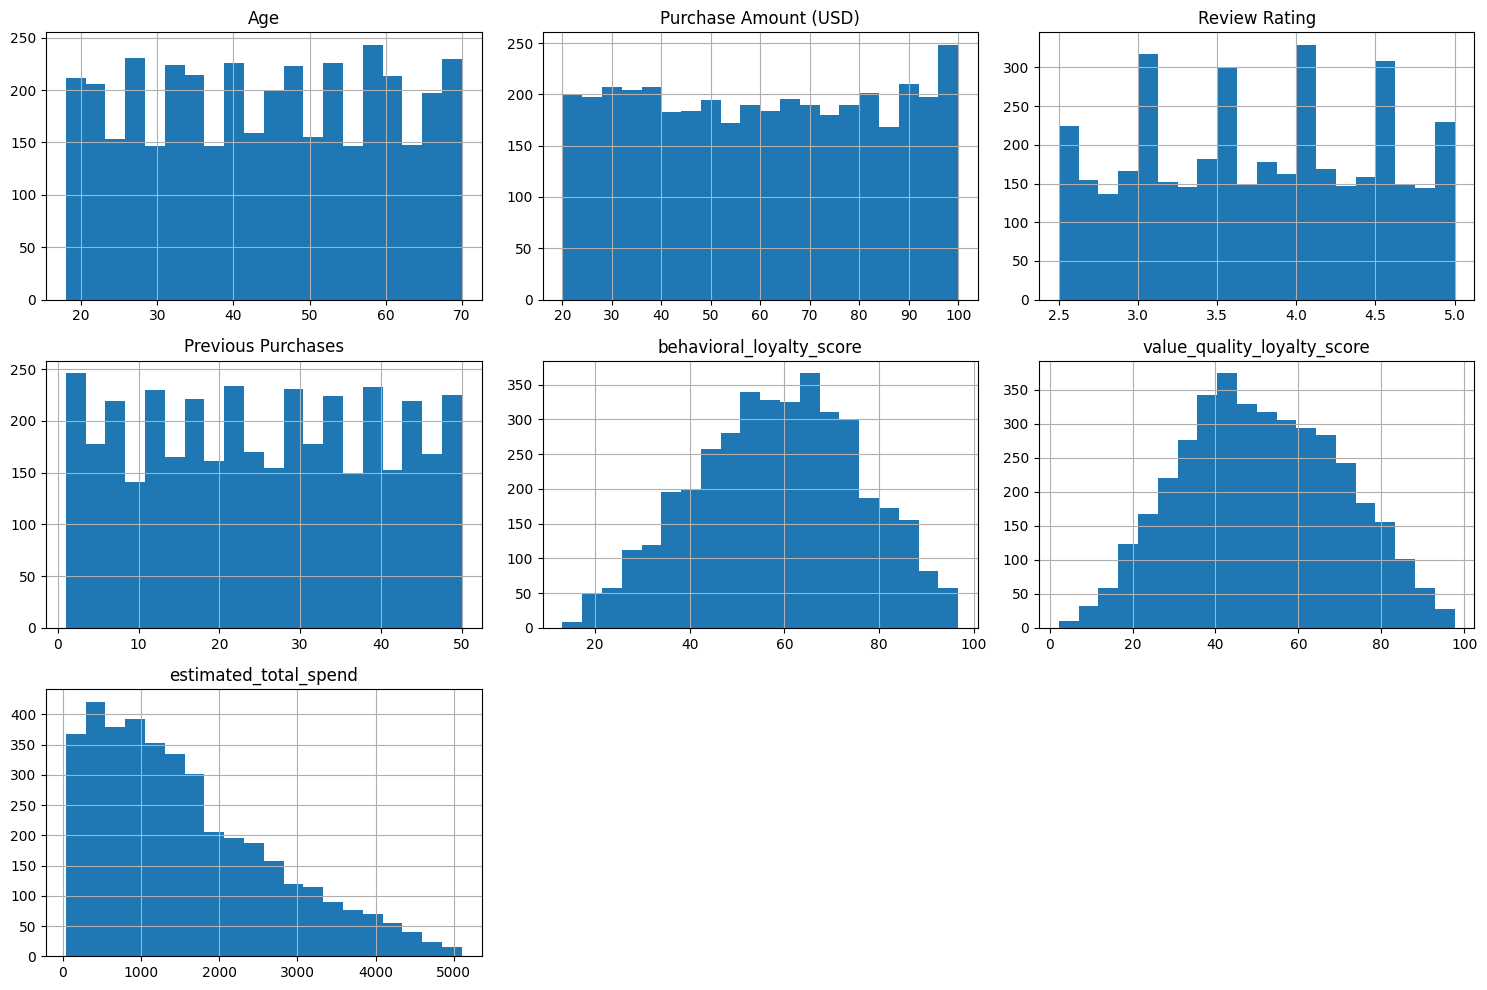

In [107]:
numerical_cols = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
    "behavioral_loyalty_score",
    "value_quality_loyalty_score",
    "estimated_total_spend"
]

df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

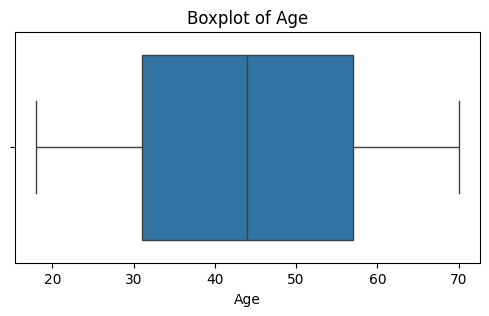

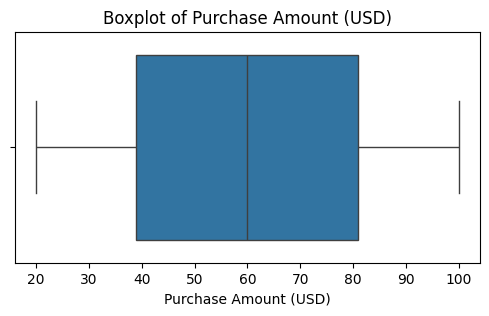

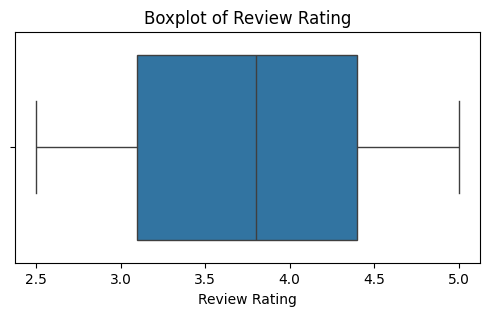

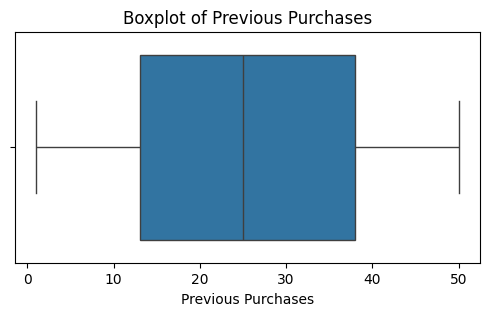

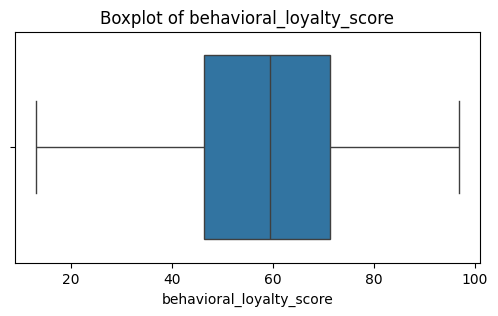

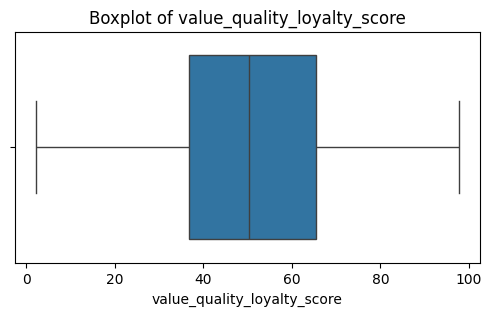

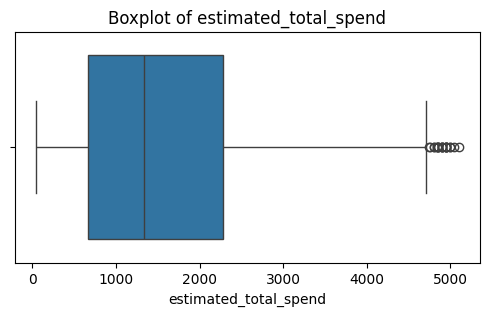

In [108]:
for col in numerical_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

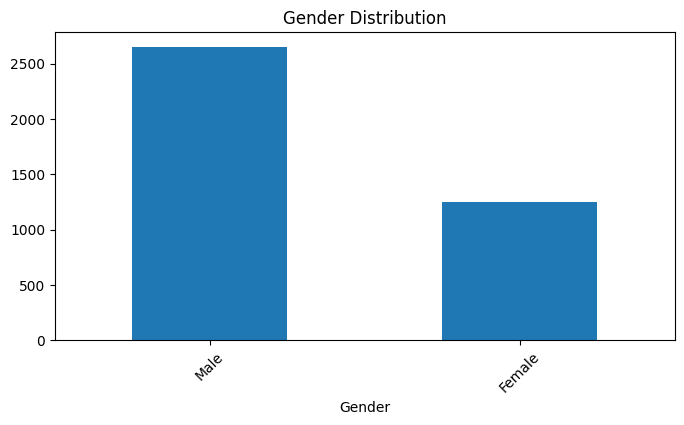

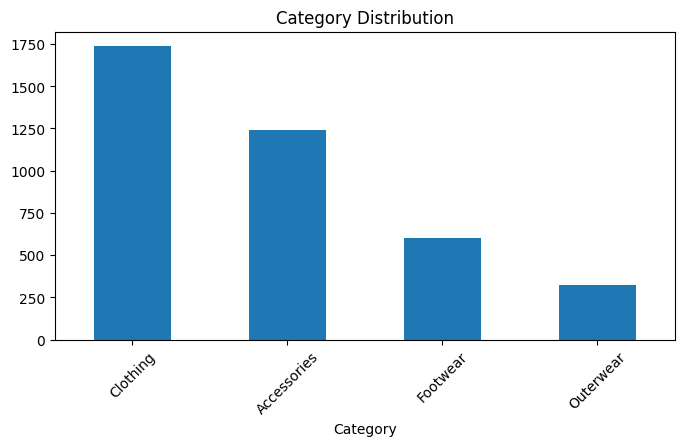

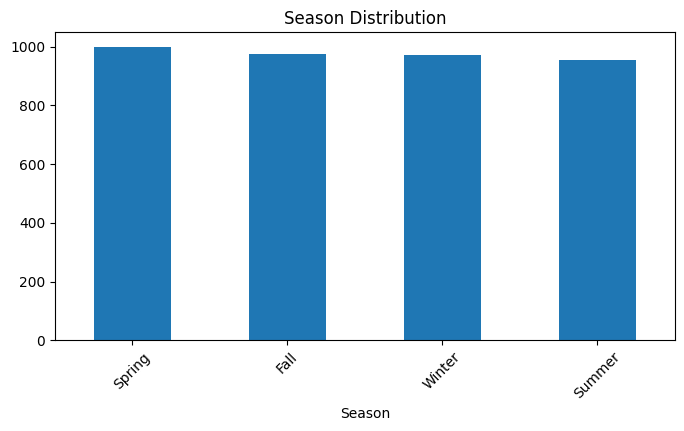

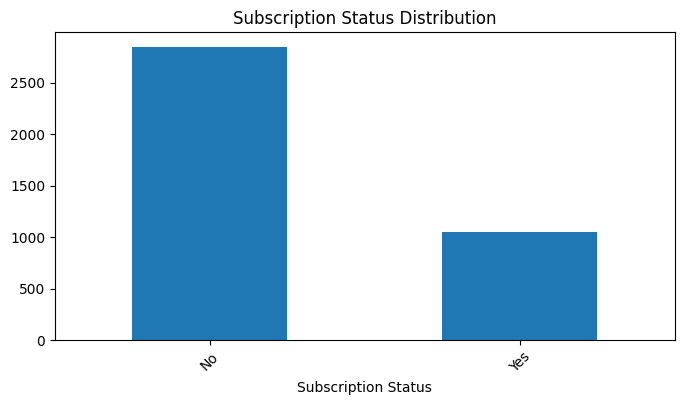

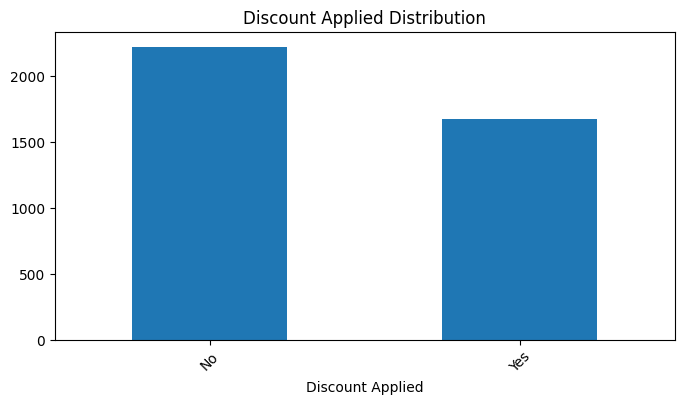

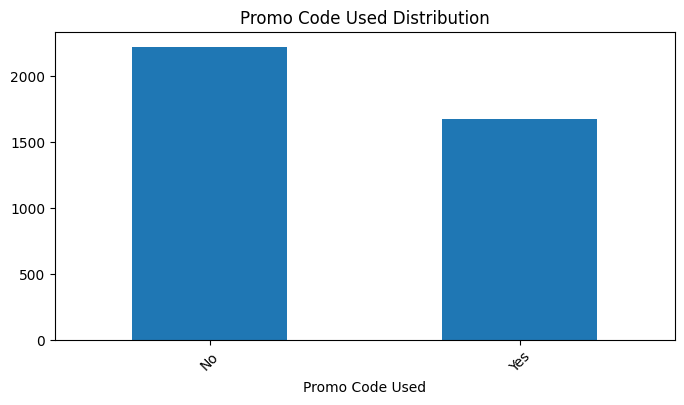

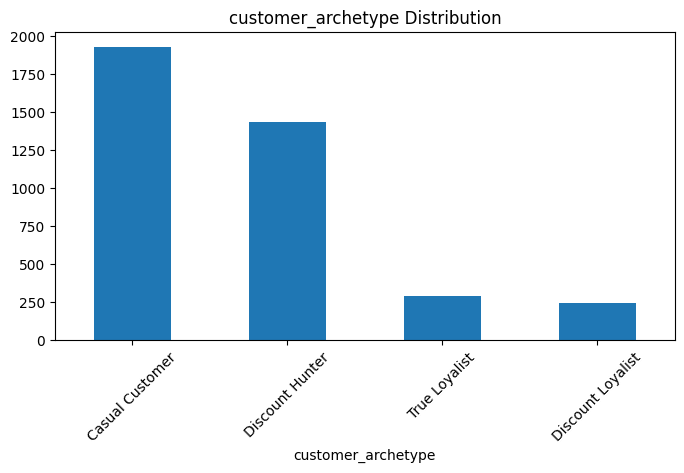

In [109]:
categorical_cols = [
    "Gender",
    "Category",
    "Season",
    "Subscription Status",
    "Discount Applied",
    "Promo Code Used",
    "customer_archetype"
]

for col in categorical_cols:

    plt.figure(figsize=(8,4))

    df[col].value_counts().plot(kind="bar")

    plt.title(f"{col} Distribution")

    plt.xticks(rotation=45)

    plt.show()

In [110]:
df.groupby("Frequency of Purchases")[[
    "Purchase Amount (USD)",
    "behavioral_loyalty_score"
]].mean()

,Purchase Amount (USD),behavioral_loyalty_score
Frequency of Purchases,,
Annually,60.173077,42.968395
Bi-Weekly,60.694698,65.800664
Every 3 Months,60.082192,50.903380
Fortnightly,59.053506,66.300013
Monthly,59.330922,58.962176
Quarterly,59.984014,52.789935
Weekly,58.972171,74.009520


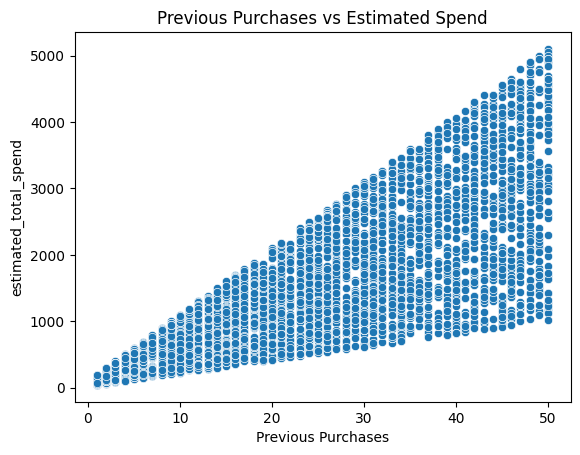

In [111]:
sns.scatterplot(
    x=df["Previous Purchases"],
    y=df["estimated_total_spend"]
)

plt.title("Previous Purchases vs Estimated Spend")

plt.show()

In [112]:
df.groupby("Subscription Status")[[
    "behavioral_loyalty_score",
    "estimated_total_spend",
    "Review Rating"
]].mean()

,behavioral_loyalty_score,estimated_total_spend,Review Rating
Subscription Status,,,
No,58.217690,1565.189673,3.751317
Yes,59.549145,1611.306743,3.748433


In [113]:
df.groupby("Payment Method")[[
    "Purchase Amount (USD)",
    "behavioral_loyalty_score"
]].mean()

,Purchase Amount (USD),behavioral_loyalty_score
Payment Method,,
Bank Transfer,59.712418,57.698068
Cash,59.704478,59.064218
Credit Card,60.074516,58.998085
Debit Card,60.915094,58.515717
PayPal,59.245199,58.467202
Venmo,58.949527,58.644738


In [114]:
df.groupby("Shipping Type")[[
    "Purchase Amount (USD)",
    "behavioral_loyalty_score"
]].mean()

,Purchase Amount (USD),behavioral_loyalty_score
Shipping Type,,
2-Day Shipping,60.733652,59.330203
Express,60.475232,58.887272
Free Shipping,60.410370,57.756054
Next Day Air,58.631173,58.204223
Standard,58.460245,59.520553
Store Pickup,59.893846,57.817976


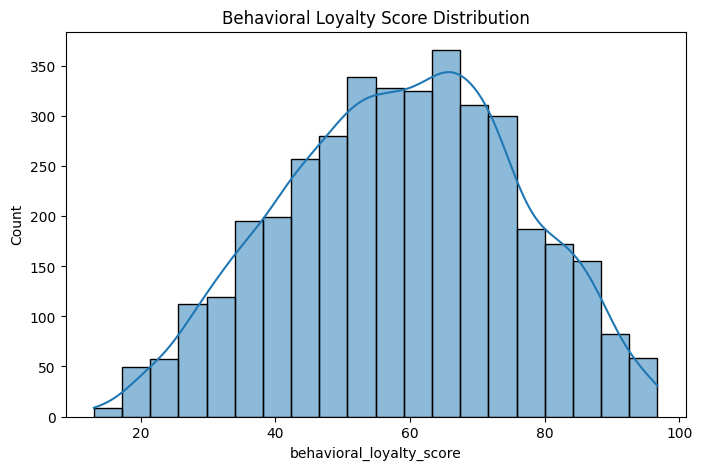

In [115]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["behavioral_loyalty_score"],
    bins=20,
    kde=True
)

plt.title("Behavioral Loyalty Score Distribution")

plt.show()